In [325]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import random
import seaborn as sns
sns.set_theme()

In [326]:
data = loadmat('cluster_dataset.mat')

In [327]:
X = data['data']
x1 = np.array([i[0] for i in X])
x2 = np.array([i[1] for i in X])

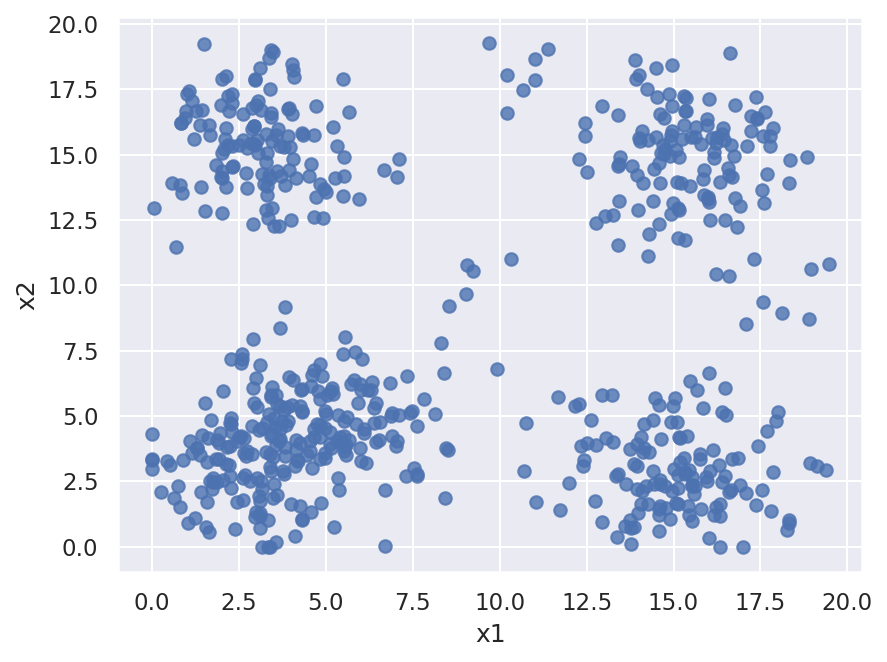

In [328]:
plt.figure(dpi=150)
plt.scatter(x1,x2,color='b',alpha=0.8)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [329]:
#预设聚类簇数k：请观察数据集散点图，预计聚类簇数k
k = 4

In [330]:
#随机选择数据集中k个点作为初始聚类中心
def init_centers(X,k):
    """
    输入：X:数据集(ndarray), k：预设的聚类簇数(int)
    输出：centers：初始化的中心集（建议：元素为ndarray的list)
    可能使用的函数：random.randint
    注意：需保证随机取的样本不重复
    """
    id = random.sample(range(len(X)) , k)
    centers = [X[j] for j in id]
    return centers

In [331]:
#向量欧氏距离计算，用于计算每个样本和中心的距离，可用于簇分配和代价函数计算
def distance(v1, v2):
    """
    输入：v1:样本(ndarray), v2:当前对应的中心(ndarray)
    输出：distance:欧氏距离(float/ndarray)
    """
    distance = np.sum((v1 - v2)**2) ** 0.5
    return distance

In [ ]:
#将样本分配到距离最近的中心所在的簇
def cluster_assignment(X, centers):
    """
    输入：X:数据集(ndarray), centers：当前中心集（建议：元素为ndarray的list)
    输出：assignment(建议：字典：key为簇标号、value为元素是ndarray的list)
    可能使用的函数：np.argmin
    注意：list和array在某些计算时的转换
    """
    k = len(centers)
    assignment = {i:[] for i in range(k)} 
    
    for i in X :
        a = np.array([distance(i , j) for j in centers])
        id = np.argmin(a)

        assignment[id].append(i)
            

    return assignment

In [333]:
#代价函数：所有数据点到当前对应中心的欧氏距离之和的平均值
def cost_function(assignment, centers):
    """
    输入：X:数据集(ndarray), centers：当前中心（建议：元素为ndarray的list)
    输出：cost:代价函数值（float/ndarray）
    可能使用的函数：np.argmin
    注意：list和array在使用np函数计算时的转换
    """
    cost1 = []
    cost = 0
    for centerid,xinc in assignment.items() :
        for i in xinc:
            cost1.append(distance(i, centers[centerid]))
    cost = np.mean(np.array(cost1))
    return cost

In [ ]:
#更新中心,满足停机条件（聚类中心不再改变）时结束更新
def center_update(assignment, centers):
    """
    输入：assignment(建议：字典：key为簇标号、value为元素是ndarray的list), centers：当前中心（建议：元素为ndarray的list)
    输出：new_centers:更新的中心集（建议：元素为ndarray的list), stop：停机条件标识（不停机：0/停机：1）
    可能使用的函数：np.mean
    注意：list和array在使用np函数计算时的转换
    """
    stop = 0
    new_centers = []
    for centerid,xinc in assignment.items() :
        x0 = np.array([i[0] for i in xinc])
        x1 = np.array([i[1] for i in xinc])
        # 防空簇除以0
        if len(centers[centerid]) == 0 :
            x0h = centers[centerid][0]
            x1h = centers[centerid][1]
        else :
            x0h = np.mean(x0)
            x1h = np.mean(x1)
        new_centers.append(np.array([x0h,x1h]))

    if all(np.array_equal(old, new) for old, new in zip(centers, new_centers)):
        stop = 1
    return new_centers, stop

In [335]:
#聚类可视化
def plot_clustering(assignment, centers, epoch):
    color = ['r', 'b', 'c', 'g', 'k', 'w', 'y', 'm']
    plt.figure(dpi=150)
    for k in range(len(centers)):
        cluster = np.array(assignment[k])
        if len(cluster) == 0:
            continue
        x1 = cluster[:,0]
        x2 = cluster[:,1]
        plt.scatter(x1, x2, c=color[k])
        plt.xlabel('x1')
        plt.ylabel('x2')
    for k in range(len(centers)):
        x1 = centers[k][0]
        x2 = centers[k][1]
        plt.scatter(x1, x2, c='k', marker = '*')
        plt.xlabel('x1')
        plt.ylabel('x2')
    plt.title('epoch'+ str(epoch))
    plt.show()

In [336]:
#kmeans及可视化
def kmeans(X, k, max_epoch, plot=True):
    """
    输入：X:数据集(ndarray), k：预设的聚类簇数(int), max_epoch：最大训练轮数(int), plot:是否可视化（True/False)
    输出：assignment(建议：字典：key为簇标号、value为元素是ndarray的list), cost:最终的代价函数值，用于k-cost曲线的绘制（float/ndarray）
    """
    centers = init_centers(X,k)
    epoch = 0
    stop = 0;
    assignment = {}
    while epoch < max_epoch and stop == 0:
        epoch += 1
        assignment = cluster_assignment(X , centers)
        centers,stop = center_update(assignment , centers)
        cost = cost_function(assignment , centers)
    if plot == True:
        plot_clustering(assignment , centers , epoch)
    return assignment, cost

In [337]:
max_epoch = 200 

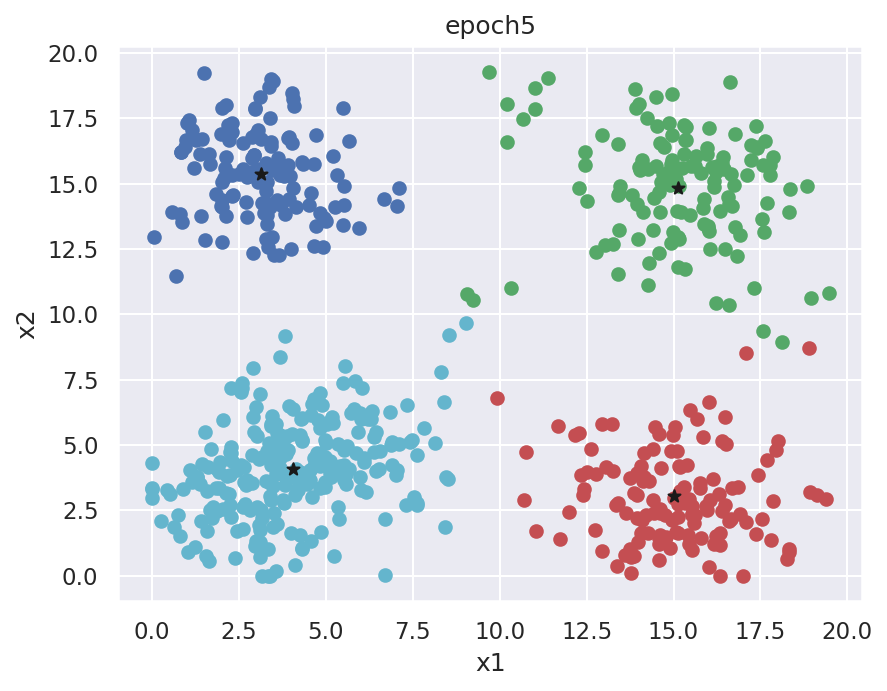

In [338]:
assignment, _ = kmeans(X, k, max_epoch)

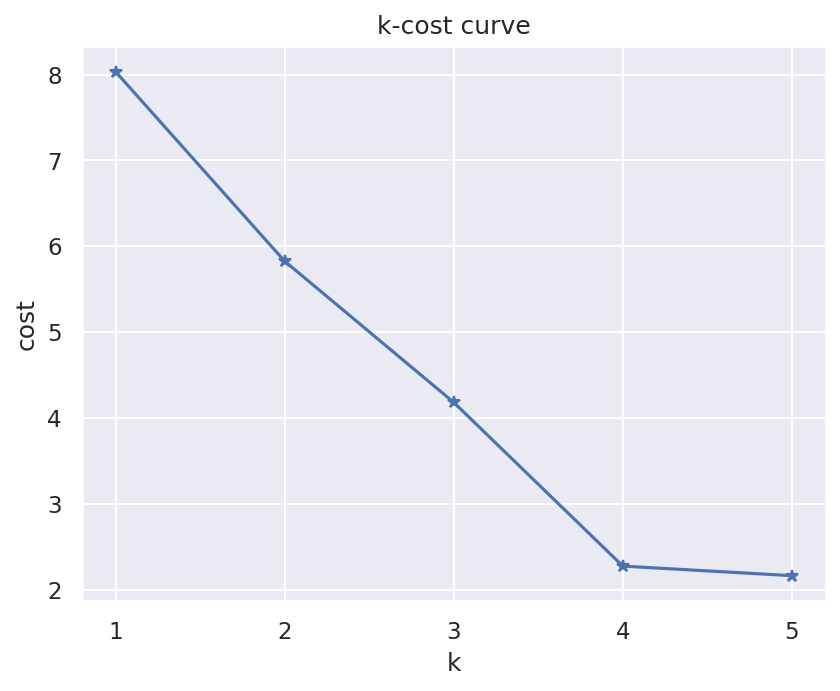

In [339]:
#绘制簇数-代价函数曲线：根据曲线，观察最合适的簇数k的选择
plt.figure(dpi=150)
Cost = []
max_k = 6
for k in range(1, max_k):
    _, cost = kmeans(X, k, max_epoch,False)
    Cost.append(cost)

plt.plot(range(1,max_k), Cost, c='b', marker = '*')
plt.xticks(range(1,max_k))
plt.xlabel('k')
plt.ylabel('cost')
plt.title('k-cost curve')
plt.show()